

# Character-level language model

In this notebook we train a language model on a small corpus and use it to generate new text in the same style. We are defining the conditional probability of the next character in a sequence given characters up until the current time. To do this we will use an LSTM.

In [1]:
# Settings for running on local machine
import os

ROOT = os.getcwd() + '/Unit4_languagemodel_Files'
print(ROOT)

C:\Users\Wes\OneDrive - University of Leeds\OCOM5203M Deep Learning\OCOM5203M_DeepLearning/Unit4_languagemodel_Files


In [2]:
import torch
from torch.utils.data import Dataset, DataLoader
from torch import nn, optim
import numpy as np
import matplotlib.pyplot as plt

# replace with your own root directory
#ROOT="C:/Users/scsdch/OneDrive - University of Leeds/Teaching/ODL Deep Learning/workspace/"

In [3]:
# Checking for GPU availability
if torch.cuda.is_available():
  device_name = torch.device('cuda')
else:
  device_name = torch.device('cpu')

print(f'Device being used: {device_name}')

Device being used: cuda


Convert characters from the text corpus into tokens from a fixed *vocabulary*.  Convert upper case letters to lower case. Characters other than letters, full-stop and space will be omitted (e.g. other punctuation, mumerical digits).  We will then use a one-hot encoding for each token as input to the RNN.

In [4]:
# character encoding: lower case letters, full-stop and space.
chars = 'abcdefghijklmnopqrstuvwxyz. '
input_size = len(chars)  # for one-hot encoding

# define a mapping from char to integer (token index) and vice versa
char_to_int = {}    # ensure the dictionaries are empty
int_to_char = {}
char_to_int = dict((c, i) for i, c in enumerate(chars))    # Creating a dictionary that assigns a number to each character in the string in ascending order
int_to_char = dict((i, c) for i, c in enumerate(chars))    # Swap the keys and items in the dictionary to reverse the encoding

def tokenize(data):
    # tokenize text string
    # convert to lower case
    data = data.lower()
    
    # integer encode (tokenize) each character; -1 if not in chars, drop these
    idx = torch.tensor([char_to_int.get(char,-1) for char in data]
                       , dtype=torch.long, device=device_name)       # Try to retrieve the character from dictionary, if not present, return -1
    idx = idx[idx != -1]                                                                    # Exclude all elements that are not equal to -1
    return idx

def onehot(idx, input_size):
    # convert to one-hot form (batch_size x sequence_length x input_size).
    # works for any tensor size and adds one-hot encoding of indices as a new dimension at the end
    inputs = torch.eye(input_size,dtype=int, device=device_name)[idx]                                          # Create a one-hot encoded identity matrix of size len(char) x len(char) and slice it so that only the rows specified by 'idx' are kept
    inputs = inputs.float()                                                                                    # Convert values in matrix to floating point
    #print(inputs.is_cuda)
    return inputs


To use the PyTorch data loader facilities, we need to define a new dataset to access the text corpus.

In [10]:
class ReadData(Dataset):
    def __init__(self, path, size):
        # read in the text and tokenize
        f = open(path, encoding='utf8')
        data = f.read()
        self.idx = tokenize(data)
        self.size = size    # the size of text windows to be used in training

    def __getitem__(self, index):
        """ Returns one data item (token sequence) """
        return self.idx[index:(index+self.size)]
        
    def __len__(self):
        return len(self.idx) - self.size

In [24]:
#data_path = 'data/alice_in_wonderland.txt'
data_path = 'data/pride_and_prejudice.txt'

dataset = ReadData(data_path, 50)
print(len(dataset))

691706


In [25]:
batch_size = 4096
train_dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

Define the network. This is an LSTM followed by a fully connected layer.

In [26]:
hidden_size = 128       # Number of nodes in the hidden layer
num_layers = 2          # Number of hidden layers

# Defining our own neural network pipeline
class MyRNN(nn.Module):
    def __init__(self, input_size):
        super(MyRNN, self).__init__()


        # "Vanilla-RNN" version
        #self.RNN = nn.RNN(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, nonlinearity='tanh', batch_first=True)
        
        # single LSTM layer, with dropout       
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)    # Creating the LSTM model - specifies everything we need to create the next hidden node and cell state
        self.dropout = nn.Dropout(0.2)                                                                                  # Specifying the level of dropout - ignored for evaluation mode
        self.linear = nn.Linear(hidden_size,input_size)                                                                 # Adding in a fully connected layer to produce the actual output
        
    def forward(self, input, zero_hidden = True):                                                                       # Defining the forward pass in the neural network
        if zero_hidden:                                                                                                 # If we have no hidden state information to pass into the network on start
            # hidden state defaults to zero
            output, hiddens = self.lstm(input)
            #output, hiddens = self.RNN(input)
        else:                                                                                                           # If we do have hidden state information to pass into the network
            # use the hidden state stored from previous invocation
            output, hiddens = self.lstm(input, self.hiddens)
            #output, hiddens = self.RNN(input, self.hiddens)
            
        
        # update stored hidden state for future invocation
        self.hiddens = hiddens
        
        output = self.dropout(output)     # If the model is in evaluation mode, this is ignored
        output = self.linear(output)      # Generating the next letter
        return output
                    
net = MyRNN(input_size)

if torch.cuda.is_available: net.cuda()

for param in net.parameters():
    print(param.shape)

torch.Size([512, 28])
torch.Size([512, 128])
torch.Size([512])
torch.Size([512])
torch.Size([512, 128])
torch.Size([512, 128])
torch.Size([512])
torch.Size([512])
torch.Size([28, 128])
torch.Size([28])


Train the network. Each window of text is trimmed by one token at the start for input and one token at the end for the target. This trains the network to predict the next character from all previous characters in the window.

`nn.LSTM` will roll-out the LSTM to operate on the given sequence. We don't need to do this explicitly. Likewise, `nn.Linear` operates independently on each time step in the time dimension. 

In [28]:
nepochs = 100
#results_path = ROOT+'/epochs'+ str(nepochs) + 'hidden' + str(hidden_size) + 'adam.pt'
#results_path = ROOT+'/RNN_epochs'+ str(nepochs) + 'hidden' + str(hidden_size) + 'adam.pt'
results_path = ROOT+'/lstm' + str(num_layers) + 'epochs'+ str(nepochs) + 'hidden' + str(hidden_size) + 'adam.pt'
print(results_path)

C:\Users\Wes\OneDrive - University of Leeds\OCOM5203M Deep Learning\OCOM5203M_DeepLearning/Unit4_languagemodel_Files/lstm2epochs100hidden128adam.pt


In [29]:
%%time
losses = np.zeros(nepochs)

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters())

net.train()                   # to be sure we are in training mode (ensures we use dropout - this is ignored in evaluation mode)
for epoch in range(nepochs):  # loop over the dataset multiple times

    running_loss = 0.0
    n = 0
    for i, idx in enumerate(train_dataloader, 0):
        inputs = onehot(idx, input_size)              # inputs is a 3 dimensional matrix: one-hot encoding 28 characters over 50 chars and 64 batches
        
        # trim to advance target by one timestep whilst keeping input and target sequences the same length
        inputs = inputs[:,:-1,:]                      # For every batch and across all one-hot encodings, remove the last char
        targets = idx[:,1:].to(device_name)           # The target is every char except the first one, which is used as the first input

         # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward, backward, and update parameters
        outputs = net(inputs).to(device_name)    # initial hidden state will default to zero, but the weights and biases will be kept across each batch
        loss = loss_fn(outputs.transpose(1,2), targets)
        loss.backward()
        optimizer.step()
    
        # accumulate loss
        running_loss += loss.item()
        n += 1
       
    losses[epoch] = meanloss = running_loss / n
    print(f"epoch: {epoch+1} loss: {meanloss : .3f}")
    
# save network parameters and losses
torch.save({"state_dict": net.state_dict(), "losses": losses}, results_path)
   

epoch: 1 loss:  2.816
epoch: 2 loss:  2.270
epoch: 3 loss:  2.020
epoch: 4 loss:  1.864
epoch: 5 loss:  1.751
epoch: 6 loss:  1.663
epoch: 7 loss:  1.594
epoch: 8 loss:  1.536
epoch: 9 loss:  1.489
epoch: 10 loss:  1.449
epoch: 11 loss:  1.415
epoch: 12 loss:  1.386
epoch: 13 loss:  1.362
epoch: 14 loss:  1.340
epoch: 15 loss:  1.321
epoch: 16 loss:  1.304
epoch: 17 loss:  1.289
epoch: 18 loss:  1.276
epoch: 19 loss:  1.263
epoch: 20 loss:  1.252
epoch: 21 loss:  1.242
epoch: 22 loss:  1.232
epoch: 23 loss:  1.223
epoch: 24 loss:  1.215
epoch: 25 loss:  1.207
epoch: 26 loss:  1.200
epoch: 27 loss:  1.193
epoch: 28 loss:  1.187
epoch: 29 loss:  1.181
epoch: 30 loss:  1.175
epoch: 31 loss:  1.170
epoch: 32 loss:  1.164
epoch: 33 loss:  1.160
epoch: 34 loss:  1.155
epoch: 35 loss:  1.151
epoch: 36 loss:  1.147
epoch: 37 loss:  1.143
epoch: 38 loss:  1.139
epoch: 39 loss:  1.136
epoch: 40 loss:  1.133
epoch: 41 loss:  1.129
epoch: 42 loss:  1.126
epoch: 43 loss:  1.124
epoch: 44 loss:  1.1

Generate novel text primed by the given prior text.

Run the model repeatedly on the currently generated text, starting with the given prior text.
Select the maximum probability token as the next token in the sequence.

In subsequent runs of the model, only input the most recently selected token since we use the final hidden state and cell state from the previous run to provide the history. 

In [31]:
# restore model parameters and losses
#results_path = ROOT+'/epochs'+ str(nepochs) + 'hidden' + str(hidden_size) + 'adam.pt'
data = torch.load(results_path)                                                        # Retrieve the parmaeters from our training
net.load_state_dict(data["state_dict"])                                                # Load the parameters into our network

# set prior text
#pretext = 'The queen turned to alice'
pretext = 'There is pride and there is prejudice'
idx = tokenize(pretext)    # initialise token sequence and generated sequence
gen_length = 400    # length of generated text
output = pretext    # initialise output text

# sample from the network.
zero_hidden = True    # initialise hidden state to zero for the first time through (as the pretext should be the first piece of new data available to the network)
net.eval()    # set eval mode so that dropout is omitted by the module
with torch.no_grad():    # turn off gradient calculations for the evaluation
    for i in range(gen_length):
        
        inputs = onehot(idx, input_size)
        inputs = torch.unsqueeze(inputs,0) # add batch dimension of size 1: 1 x len(idx) x input_size
        
        outputs = net(inputs, zero_hidden)

        # torch.max finds the maximum value of dimension 2 in outputs
        #     Dimension 2 is where the Hidden State is stored when batch_first=True
        # This function returns two variables:
        #     _ are the hidden state values
        #     predicted are the indices of those hidden state values mapped against the one-hot encoding matrix
        _, predicted = torch.max(outputs, 2)

        # extract final predicted token as input for next timestep
        # predicted returns the next best guess for every input character in the string
        token = predicted[0,-1].item()
        output = output + int_to_char[token]       # decode token and append to output
        idx = torch.tensor([token])    # input sequence consisting of a single time step
        zero_hidden = False               # pass on the hidden state in future iterations
          
print(output)   

There is pride and there is prejudicer assured with her sister and i am sure i am sure in the same time that is the lady catherine and her sister was answer and the same time that is the lady was so much to the truth of her family and in the country and they were all the compliment of her former fathers appearance and the same time that is the lady catherine de bourgh and her sister and her sister and i am sure i am sure in the same 


Plot the mean loss after each epoch.

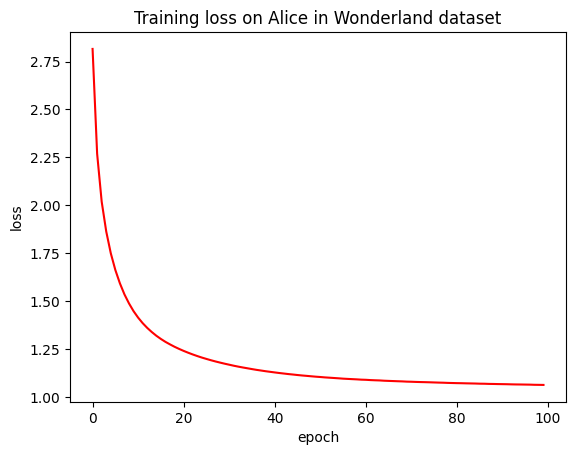

In [32]:
# restore model parameters and losses
#results_path = ROOT+'results/epochs50hidden128adam.pt'
data = torch.load(results_path)
losses = data["losses"]

plt.plot(losses, 'r')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('Training loss on Alice in Wonderland dataset' )
plt.show()